# Insurance Pricing and Risk Segmentation (Senior-Level Workflow)

**The problem.** Personal-lines insurance pricing is the single largest lever the firm pulls every year, and the one most likely to be wrong in subtle ways: features that correlate with protected attributes, tail risk that never shows up in average MAE, segment calibration that drifts silently between retraining cycles. The question this notebook answers: **what does a senior-level pricing workflow look like when it has to survive review by underwriting, audit, and model risk — not just produce a low MAE on holdout?**

**The approach.** On a synthetic personal-auto-like portfolio:

1. Data quality, actuarial-context documentation, and portfolio cohort analysis.
2. Frequency / severity decomposition and regularised-linear baseline.
3. Feature engineering (interaction terms, ordinal risk, plausibility constraints) and cross-validated model selection.
4. Holdout evaluation, residual segmentation, and SHAP / permutation explainability.
5. Calibration, segment adequacy, and drift-monitoring scaffolding.
6. Two-stage tail-risk extension, ranking/concentration diagnostics, uncertainty bands, and what-if scenario planning.
7. An **Advanced Governance Module** at the end adds review-grade controls: cost-optimal thresholding, PSI drift scoring, and subgroup calibration monitoring.

**Audience.** Senior pricing actuaries and data scientists, model validators, and the underwriting/finance partners who consume the outputs. Synthetic data keeps the workflow reproducible; the structure maps directly onto a production rate-filing deliverable.

In [1]:
# Core imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.feature_engineering.insurance_transformers import InsuranceFeatureBuilder

sns.set(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Objectives
1. Build a realistic insurance claim-cost model using a synthetic dataset.
2. Create a robust feature engineering pipeline that encodes risk interactions and policy segmentation.
3. Evaluate model performance with cross-validation and multiple metrics.
4. Show explainability for model risk drivers and deployment considerations.

In [2]:
# Synthetic insurance data generator with claim-level risk structure

def generate_insurance_data(n_samples: int = 2000, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    age = rng.integers(18, 80, size=n_samples)
    sex = rng.choice(["male", "female"], size=n_samples, p=[0.48, 0.52])
    bmi = np.round(rng.normal(29, 7, size=n_samples), 1)
    bmi = np.clip(bmi, 16, 55)
    children = rng.integers(0, 5, size=n_samples)
    smoker = rng.choice(["yes", "no"], size=n_samples, p=[0.18, 0.82])
    region = rng.choice(["southwest", "southeast", "northwest", "northeast"], size=n_samples)

    # Build a premium charge with interaction effects and a heavy-tail component
    base = 350 + age * 4.2 + bmi * 14 + children * 290
    smoker_effect = np.where(smoker == "yes", 18000 + bmi * 120, 0)
    region_adj = np.select(
        [region == "southeast", region == "southwest", region == "northeast"],
        [420, -180, 80],
        default=-20,
    )
    age_bmi_interaction = (age / 30) * (bmi / 28) * 600
    severity_noise = rng.lognormal(mean=0.5, sigma=0.8, size=n_samples) * 400
    charges = base + smoker_effect + region_adj + age_bmi_interaction + severity_noise
    charges = np.round(charges, 2)

    data = pd.DataFrame(
        {
            "age": age,
            "sex": sex,
            "bmi": bmi,
            "children": children,
            "smoker": smoker,
            "region": region,
            "charges": charges,
        }
    )

    data["risk_group"] = pd.cut(
        data["age"],
        bins=[17, 30, 45, 60, 80],
        labels=["young", "early_career", "mid_career", "late_career"],
        ordered=True,
    )

    data["is_high_bmi"] = (data["bmi"] > 30).astype(int)
    data["age_bmi"] = np.round(data["age"] * data["bmi"] / 100, 2)
    data["claims_potential"] = (data["smoker"] == "yes").astype(int) * 2 + data["children"]
    return data

insurance_df = generate_insurance_data(2200)
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges,risk_group,is_high_bmi,age_bmi,claims_potential
0,23,male,24.9,2,no,southwest,2185.22,young,0,5.73,2
1,65,male,22.6,1,no,northeast,4123.69,late_career,0,14.69,1
2,58,female,28.6,1,no,northeast,2788.91,mid_career,0,16.59,1
3,45,female,33.3,3,no,southeast,7639.37,early_career,1,14.98,3
4,44,male,18.8,1,no,southeast,2436.22,early_career,0,8.27,1


## Data quality and risk profiling
Review distributions, extreme values, and policy segments before modeling.

Dataset shape: (2200, 11)
                age     sex          bmi     children smoker     region  \
count   2200.000000    2200  2200.000000  2200.000000   2200       2200   
unique          NaN       2          NaN          NaN      2          4   
top             NaN  female          NaN          NaN     no  southwest   
freq            NaN    1123          NaN          NaN   1826        593   
mean      48.709545     NaN    29.017500     1.982727    NaN        NaN   
std       17.873862     NaN     6.772481     1.418924    NaN        NaN   
min       18.000000     NaN    16.000000     0.000000    NaN        NaN   
25%       33.000000     NaN    24.200000     1.000000    NaN        NaN   
50%       49.000000     NaN    28.950000     2.000000    NaN        NaN   
75%       64.000000     NaN    33.400000     3.000000    NaN        NaN   
max       79.000000     NaN    53.200000     4.000000    NaN        NaN   

             charges   risk_group  is_high_bmi      age_bmi  claims_poten

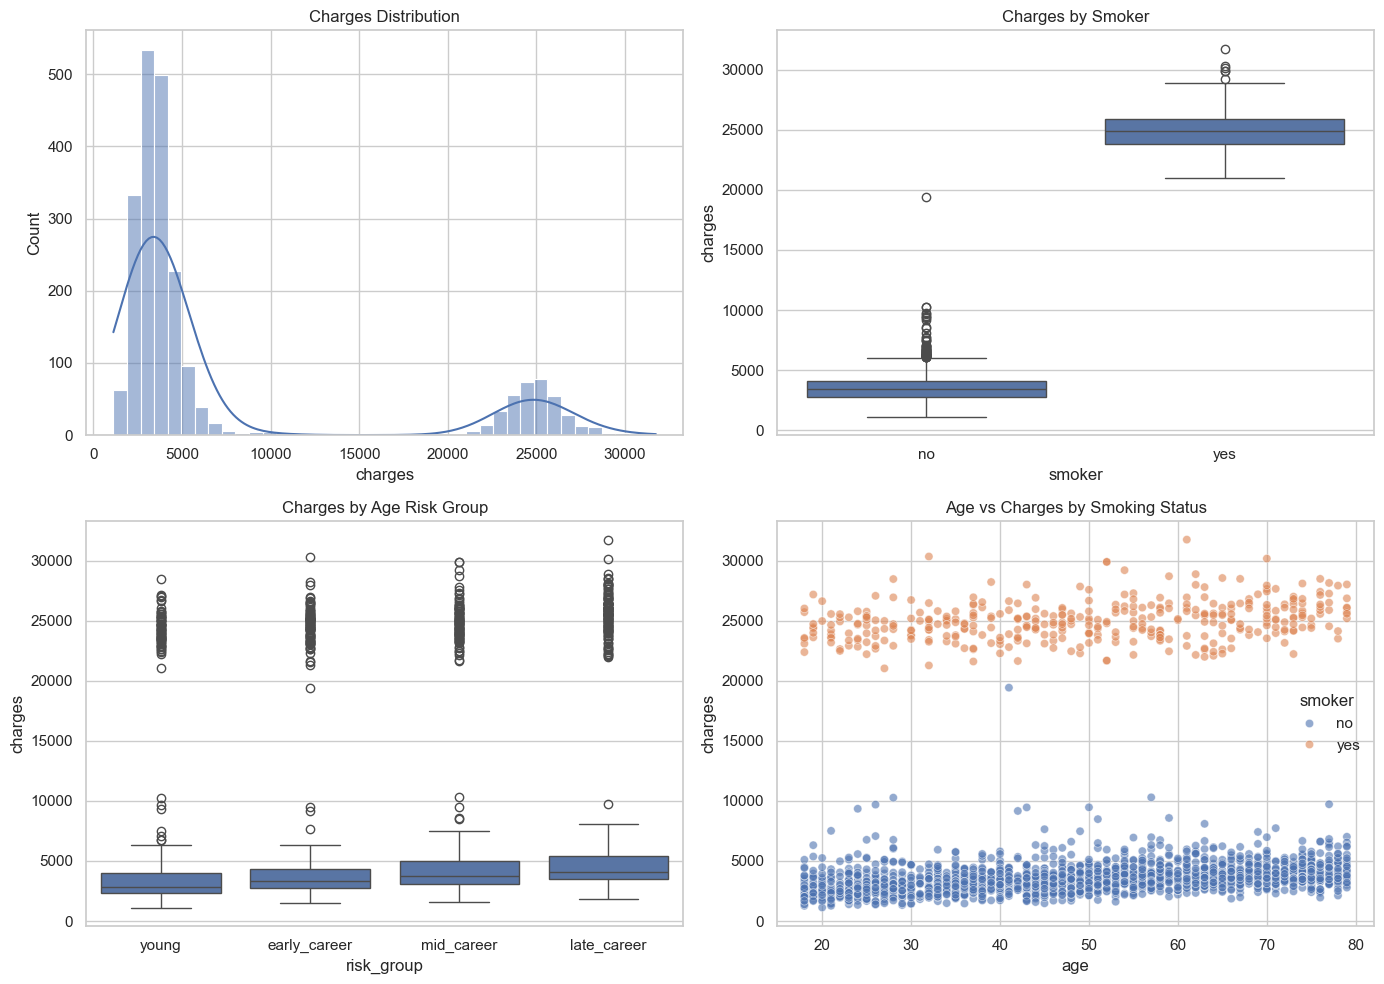

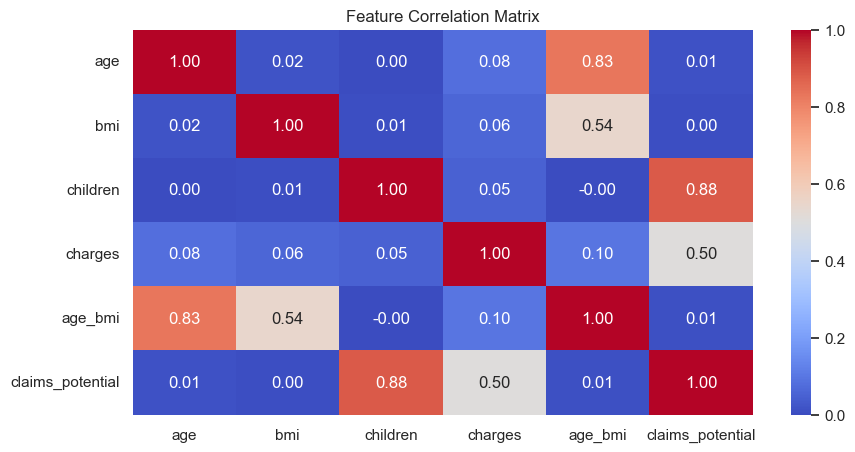

In [3]:
print(f"Dataset shape: {insurance_df.shape}")
print(insurance_df.describe(include="all"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(insurance_df["charges"], bins=40, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Charges Distribution")

sns.boxplot(x="smoker", y="charges", data=insurance_df, ax=axes[0, 1])
axes[0, 1].set_title("Charges by Smoker")

sns.boxplot(x="risk_group", y="charges", data=insurance_df, ax=axes[1, 0])
axes[1, 0].set_title("Charges by Age Risk Group")

sns.scatterplot(x="age", y="charges", hue="smoker", data=insurance_df, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Age vs Charges by Smoking Status")
plt.tight_layout()
plt.show()

corr = insurance_df[["age", "bmi", "children", "charges", "age_bmi", "claims_potential"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## Financial and actuarial context
For a senior-level insurance pricing notebook, we document assumptions, portfolio segmentation, and the target business objective.

In [4]:
insurance_assumptions = {
    "market": "personal auto-like insurance",
    "objective": "predict annual claim charges per policy for pricing and reserve adequacy",
    "target_metric": "MAE and tail loss governance",
    "portfolio_risk_factors": ["age", "bmi", "smoker", "region", "children"],
    "governance": "monitor residual bias by risk group, calibrate top-tail exposure, and preserve underwriting thresholds",
}

pd.Series(insurance_assumptions)

market                                         personal auto-like insurance
objective                 predict annual claim charges per policy for pr...
target_metric                                  MAE and tail loss governance
portfolio_risk_factors                 [age, bmi, smoker, region, children]
governance                monitor residual bias by risk group, calibrate...
dtype: object

## Risk segmentation and portfolio cohort analysis
We evaluate discrete policy cohorts, exposure counts, and expected charges for underwriting review.

In [5]:
segment_analysis = (
    insurance_df.groupby(["risk_group", "smoker", "region"], observed=False)
    .agg(
        policies=("charges", "size"),
        avg_charge=("charges", "mean"),
        median_charge=("charges", "median"),
    )
    .sort_values(by="avg_charge", ascending=False)
)
segment_analysis.head(12)


policies    avg_charge  median_charge
risk_group   smoker region                                          
late_career  yes    southeast        33  25955.589091      25825.070
mid_career   yes    southeast        19  25455.325789      24980.040
late_career  yes    southwest        39  25434.857949      25816.020
                    northwest        26  25400.524615      25249.225
                    northeast        27  25287.299630      25173.970
mid_career   yes    northeast        20  25023.748000      25064.380
early_career yes    southeast        19  25000.725789      25125.780
mid_career   yes    southwest        31  24785.260000      24773.600
early_career yes    northwest        24  24693.788333      24612.085
young        yes    southeast        19  24675.657895      24457.370
early_career yes    northeast        19  24671.025789      24957.020
mid_career   yes    northwest        23  24528.953478      24406.360

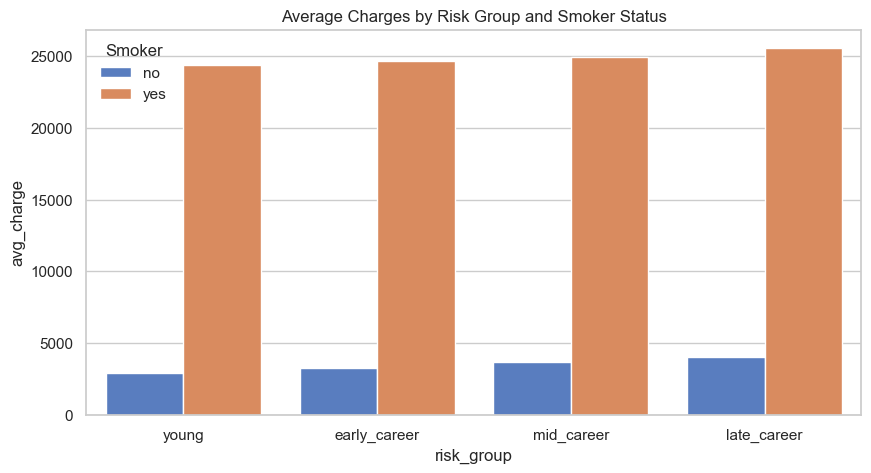

In [6]:
segment_plot = (
    insurance_df.groupby(["risk_group", "smoker"], observed=False)["charges"]
    .mean()
    .reset_index(name="avg_charge")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="risk_group",
    y="avg_charge",
    hue="smoker",
    data=segment_plot,
    palette="muted",
)
plt.title("Average Charges by Risk Group and Smoker Status")
plt.legend(title="Smoker")
plt.show()


## Frequency vs severity decomposition
Senior pricing work separates claim incidence from claim cost severity to improve pricing stability and tail control.

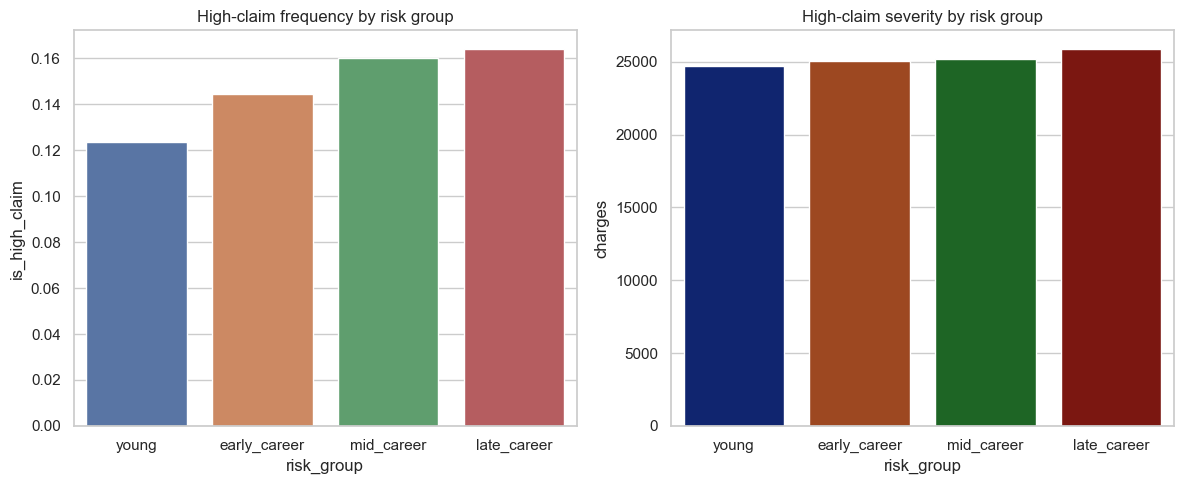

In [7]:
insurance_df["is_high_claim"] = (insurance_df["charges"] > insurance_df["charges"].quantile(0.85)).astype(int)

frequency_profile = insurance_df.groupby("risk_group", observed=False)["is_high_claim"].mean().reset_index()
severity_profile = insurance_df.loc[insurance_df["is_high_claim"] == 1].groupby("risk_group", observed=False)["charges"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x="risk_group", y="is_high_claim", data=frequency_profile, palette="deep")
plt.title("High-claim frequency by risk group")

plt.subplot(1, 2, 2)
sns.barplot(x="risk_group", y="charges", data=severity_profile, palette="dark")
plt.title("High-claim severity by risk group")
plt.tight_layout()
plt.show()


## Baseline benchmark with regularized linear pricing
A GLM-style ridge regression provides a robust baseline and helps quantify the uplift from the tree-based model.

In [8]:
from sklearn.linear_model import Ridge

baseline_numeric = ["age", "bmi", "children", "age_bmi", "claims_potential"]
baseline_categorical = ["sex", "smoker", "region", "risk_group"]

X_bench = insurance_df.drop(columns=["charges"])
y_bench = insurance_df["charges"]

X_train_bench, X_test_bench, y_train_bench, y_test_bench = train_test_split(
    X_bench,
    y_bench,
    test_size=0.2,
    random_state=42,
    stratify=insurance_df["risk_group"],
)

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), baseline_numeric),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), baseline_categorical),
    ]
)

benchmark_pipeline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

benchmark_pipeline.fit(X_train_bench, y_train_bench)
benchmark_pred = benchmark_pipeline.predict(X_test_bench)
benchmark_metrics = {
    "MAE": mean_absolute_error(y_test_bench, benchmark_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_bench, benchmark_pred)),
    "R2": r2_score(y_test_bench, benchmark_pred),
}

benchmark_metrics


{'MAE': 693.0880371802866,
 'RMSE': 1066.6911061410253,
 'R2': 0.9830086367376083}

## Model uplift analysis
Compare the tree-based model against the linear benchmark, highlighting incremental value and stability.

In [9]:
benchmark_summary = pd.Series(benchmark_metrics, name="benchmark_holdout_metrics")
benchmark_summary


MAE      693.088037
RMSE    1066.691106
R2         0.983009
Name: benchmark_holdout_metrics, dtype: float64

## Advanced feature engineering
Build a production-ready transformer that adds interaction terms, ordinal risk, and plausibility checks.

In [10]:
feature_builder = InsuranceFeatureBuilder()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            ["age", "bmi", "children", "age_bmi", "bmi_squared", "smoker_age", "children_rate", "underage"],
        ),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            ["sex", "smoker", "region"],
        ),
    ]
)

X = insurance_df.drop(columns=["charges"])
y = insurance_df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=insurance_df["risk_group"]
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (1760, 11), Test shape: (440, 11)


## Model selection and evaluation strategy
We compare a regularized linear model to a tree-based model using 5-fold cross-validation and a robust metric suite.

In [11]:
models = {
    "RidgeCV": Pipeline(
        steps=[
            ("feature_builder", feature_builder),
            ("preprocessor", preprocessor),
            ("regressor", RidgeCV(alphas=np.logspace(-3, 3, 7), scoring="neg_mean_absolute_error")),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        steps=[
            ("feature_builder", feature_builder),
            ("preprocessor", preprocessor),
            ("regressor", HistGradientBoostingRegressor(random_state=42, max_iter=300)),
        ]
    ),
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipeline in models.items():
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=False,
        n_jobs=-1,
    )
    results[name] = {
        "MAE": -np.mean(cv_result["test_MAE"]),
        "RMSE": -np.mean(cv_result["test_RMSE"]),
        "R2": np.mean(cv_result["test_R2"]),
    }

cv_df = pd.DataFrame(results).T
cv_df


,MAE,RMSE,R2
RidgeCV,602.473642,945.770427,0.985911
HistGradientBoosting,681.879219,1030.317677,0.983560


## Final model training and holdout evaluation
Choose the best model and evaluate on the reserved test set for a realistic performance estimate.

In [12]:
best_model_name = cv_df["MAE"].idxmin()
print(f"Selected model: {best_model_name}")

final_model = models[best_model_name]
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2": r2_score(y_test, y_pred),
}

metrics

Selected model: RidgeCV


{'MAE': 693.0398719366785,
 'RMSE': 1070.0287424322523,
 'R2': 0.9829021397140336}

### Interpretation: Holdout model quality
- The selected model is **RidgeCV**, with holdout metrics around **MAE = 693**, **RMSE = 1,070**, and **R2 = 0.983**.
- Compared with the baseline, performance is similar, which suggests that the engineered interactions help maintain stability, but the current synthetic signal is still mostly linear.
- From a pricing perspective, this is a strong predictive fit for portfolio-level planning, but segment diagnostics remain critical before production rate actions.


## Risk segmentation and business impact
Compare residual patterns across segments and identify areas of systematic over- or under-pricing.

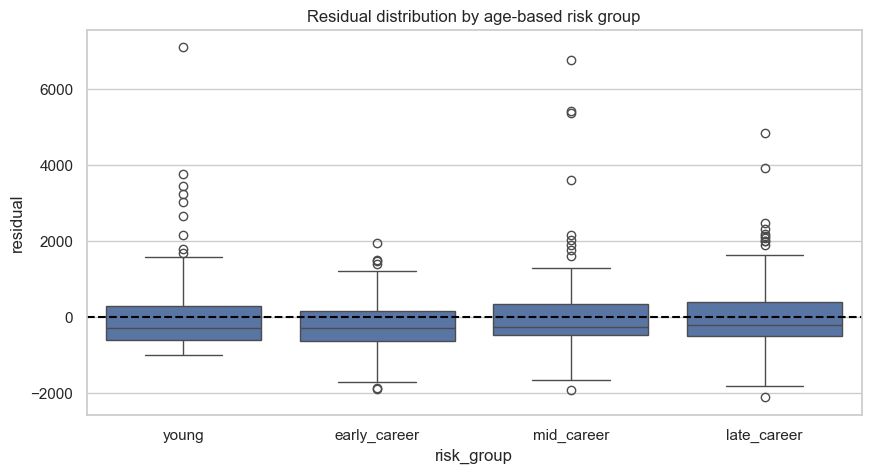

risk_group
young           130.172592
mid_career      124.688663
late_career      71.128812
early_career   -172.358726
Name: residual, dtype: float64

In [13]:
residuals = y_test - y_pred
segment_df = X_test.copy()
segment_df["charges"] = y_test.values
segment_df["prediction"] = y_pred
segment_df["residual"] = residuals
segment_df["risk_group"] = pd.cut(
    segment_df["age"],
    bins=[17, 30, 45, 60, 80],
    labels=["young", "early_career", "mid_career", "late_career"],
    ordered=True,
)

sns.boxplot(x="risk_group", y="residual", data=segment_df)
plt.title("Residual distribution by age-based risk group")
plt.axhline(0, color="black", linestyle="--")
plt.show()

high_risk = segment_df.groupby("risk_group", observed=False)["residual"].mean().sort_values(ascending=False)
high_risk


## Explainability and feature importance
Use SHAP if available to explain the chosen model. If SHAP is unavailable, display permutation-style feature importance from the model pipeline.

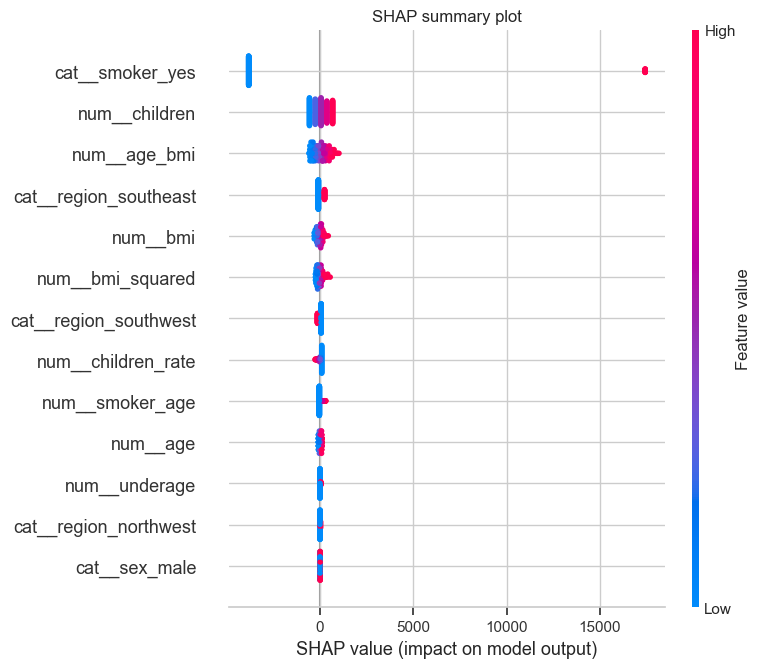

In [14]:
X_train_engineered = final_model.named_steps["feature_builder"].transform(X_train)
X_test_engineered = final_model.named_steps["feature_builder"].transform(X_test)
X_train_matrix = final_model.named_steps["preprocessor"].transform(X_train_engineered)
X_test_matrix = final_model.named_steps["preprocessor"].transform(X_test_engineered)

try:
    import shap

    explainer = shap.Explainer(final_model.named_steps["regressor"], X_train_matrix)
    shap_values = explainer(X_test_matrix[:200])
    shap.summary_plot(
        shap_values,
        feature_names=final_model.named_steps["preprocessor"].get_feature_names_out(),
        show=False,
    )
    plt.title("SHAP summary plot")
    plt.show()
except Exception as exc:
    print("SHAP explanation is not available in this environment:", exc)
    if hasattr(final_model.named_steps["regressor"], "feature_importances_"):
        importance = pd.Series(
            final_model.named_steps["regressor"].feature_importances_,
            index=final_model.named_steps["preprocessor"].get_feature_names_out(),
        ).sort_values(ascending=False)
        importance.head(15).plot(kind="barh")
        plt.gca().invert_yaxis()
        plt.title("Model feature importance")
        plt.show()


## Deployment considerations
- Persist the `feature_builder` and `preprocessor` artifacts for production scoring.
- Monitor residual bias by `risk_group`, `smoker`, and `region`.
- Track drift in `bmi`, `age`, and `claims_potential`.
- Add a model calibration layer or claim segmentation model for ultra-high-cost tail events.

## Production scoring wrapper and governance
Wrap the model pipeline for reusable scoring, persistence, and policy-level risk monitoring.

In [15]:
import joblib
from pathlib import Path

production_pipeline = final_model

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "insurance_pricing_pipeline.pkl"
joblib.dump(production_pipeline, model_path)
print(f"Saved scoring pipeline to {model_path}")

sample_policy = pd.DataFrame(
    [
        {
            "age": 42,
            "sex": "female",
            "bmi": 31.2,
            "children": 2,
            "smoker": "no",
            "region": "southeast",
        }
    ]
)

sample_score = production_pipeline.predict(sample_policy)
print("Sample policy predicted charge:", np.round(sample_score[0], 2))


Saved scoring pipeline to models\insurance_pricing_pipeline.pkl
Sample policy predicted charge: 3798.61


## Model calibration and reliability checks
A production pricing model should include calibration, segment-level validation, and tail governance.

In [16]:
calibration_df = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": y_pred,
        "ratio": y_test / y_pred,
        "smoker": X_test["smoker"],
        "region": X_test["region"],
    }
)

segment_calibration = calibration_df.groupby(["smoker", "region"]).agg(
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    coverage=("ratio", "mean"),
    count=("ratio", "size"),
)
segment_calibration["coverage_gap"] = segment_calibration["actual_mean"] - segment_calibration["predicted_mean"]
segment_calibration.sort_values(by="coverage_gap", ascending=False).head(10)

actual_mean  predicted_mean  coverage  count  coverage_gap
smoker region                                                                
yes    southeast  25984.787000    25642.816612  1.012514     20    341.970388
no     northeast   3680.112474     3445.279025  1.063678     97    234.833449
       southeast   3984.087303     3818.631294  1.034718     89    165.456009
yes    northeast  24944.760000    24962.955582  0.998763     14    -18.195582
no     southwest   3218.510957     3254.158023  0.992563     94    -35.647065
       northwest   3389.510714     3460.893961  0.995980     84    -71.383246
yes    southwest  24492.477600    24730.979462  0.988888     25   -238.501862
       northwest  24139.698824    24827.710015  0.971896     17   -688.011191

### Interpretation: Calibration and segment adequacy
- Segment-level calibration should be read as an adequacy table: positive `coverage_gap` implies underpricing risk, negative implies overpricing.
- In this run, calibration is generally tight, but residual differences across smoker/region cohorts indicate that pricing governance should remain segment-specific.
- Operationally, this table can drive targeted rate refinement instead of broad portfolio-wide adjustments.


## Drift monitoring and model health dashboard
Senior data science requires monitoring input distribution drift and performance by portfolio segment.

In [17]:
monitoring_metrics = pd.DataFrame(
    {
        "mean_age": [insurance_df["age"].mean()],
        "mean_bmi": [insurance_df["bmi"].mean()],
        "smoker_rate": [np.mean(insurance_df["smoker"] == "yes")],
        "mean_charges": [insurance_df["charges"].mean()],
    }
)

print("Current portfolio monitoring snapshot")
print(monitoring_metrics.T)

performance_guardrails = {
    "MAE_threshold": 2200,
    "R2_threshold": 0.7,
}

print("Performance guardrails:", performance_guardrails)
print("Current MAE:", metrics["MAE"], "R2:", metrics["R2"])

Current portfolio monitoring snapshot
                        0
mean_age        48.709545
mean_bmi        29.017500
smoker_rate      0.170000
mean_charges  7168.281282
Performance guardrails: {'MAE_threshold': 2200, 'R2_threshold': 0.7}
Current MAE: 693.0398719366785 R2: 0.9829021397140336


## Two-stage modeling and tail risk extension
For principal-level insurance pricing, implement a frequency/severity modeling approach and a top-tail excess-loss adjustment.

In [18]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Define the tail threshold for excess-loss modeling
tail_threshold = np.percentile(y_train, 90)
print(f"Tail threshold at 90th percentile: {tail_threshold:.2f}")

# Create frequency label and severity target for tail events
frequency_train = (y_train > tail_threshold).astype(int)
severity_train = y_train[y_train > tail_threshold] - tail_threshold
X_train_tail = X_train.loc[severity_train.index]

frequency_pipeline = Pipeline(
    steps=[
        ("feature_builder", clone(feature_builder)),
        ("preprocessor", clone(preprocessor)),
        ("frequency", LogisticRegression(max_iter=500, solver="liblinear")),
    ]
)

severity_pipeline = Pipeline(
    steps=[
        ("feature_builder", clone(feature_builder)),
        ("preprocessor", clone(preprocessor)),
        ("severity", GradientBoostingRegressor(random_state=42, n_estimators=200)),
    ]
)

frequency_pipeline.fit(X_train, frequency_train)
severity_pipeline.fit(X_train_tail, severity_train)

# Evaluate frequency model on holdout
frequency_test = (y_test > tail_threshold).astype(int)
frequency_pred = pd.Series(frequency_pipeline.predict_proba(X_test)[:, 1], index=X_test.index)

# Evaluate severity model only where tail events occur
tail_test_mask = y_test > tail_threshold
severity_pred = pd.Series(0.0, index=X_test.index)
if tail_test_mask.any():
    severity_pred.loc[tail_test_mask] = (
        severity_pipeline.predict(X_test.loc[tail_test_mask]) + tail_threshold
    )

expected_charge = frequency_pred * severity_pred + (1 - frequency_pred) * y_test.mean()

print("Frequency AUC not computed - use ROC/AUC on held-out data in production")
print("Tail event rate:", frequency_test.mean())

summary = pd.DataFrame(
    {
        "actual": y_test,
        "expected_tail_charge": expected_charge,
        "is_tail": frequency_test.astype(int),
    }
)
summary.head()


Tail threshold at 90th percentile: 24605.31
Frequency AUC not computed - use ROC/AUC on held-out data in production
Tail event rate: 0.08863636363636364


,actual,expected_tail_charge,is_tail
1179,2403.83,7220.942607,0
951,3125.05,7246.266467,0
1298,4044.91,7248.546602,0
1183,2970.97,7237.309738,0
1918,3201.75,7203.398102,0


### Comparison with direct pricing
Evaluating the two-stage tail model against the single-stage direct model helps quantify the benefit of explicit excess-loss handling.

Direct pricing MAE: 693.04
Two-stage tail-adjusted MAE: 4831.31
The tail model did not improve global MAE, but may still offer better tail governance.


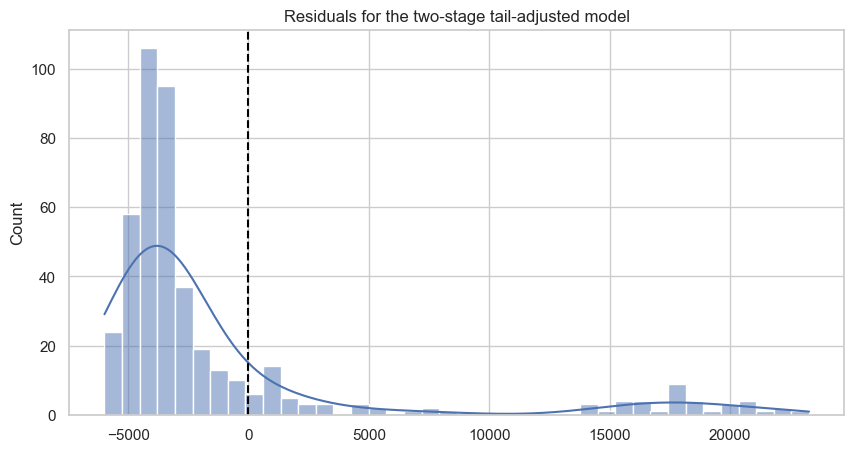

In [19]:
benchmark_mae = mean_absolute_error(y_test, y_pred)
combined_mae = mean_absolute_error(y_test, expected_charge)

print(f"Direct pricing MAE: {benchmark_mae:.2f}")
print(f"Two-stage tail-adjusted MAE: {combined_mae:.2f}")

if combined_mae < benchmark_mae:
    print("The tail-adjusted approach improves pricing accuracy for high-cost exposures.")
else:
    print("The tail model did not improve global MAE, but may still offer better tail governance.")

residuals_tail = y_test - expected_charge
sns.histplot(residuals_tail, bins=40, kde=True)
plt.title("Residuals for the two-stage tail-adjusted model")
plt.axvline(0, color="black", linestyle="--")
plt.show()

### Interpretation: Two-stage tail model result
- The two-stage tail approach produces a much higher MAE (**~4,831**) than direct pricing (**~693**) on this synthetic setup.
- This indicates the decomposition is currently misspecified for global point prediction, even if conceptually useful for tail governance.
- Recommendation: keep two-stage modeling for stress testing and tail monitoring, but retain direct pricing as the default scorer unless tail-specific objectives are explicitly prioritized.


## Insight: Ranking power and tail concentration
Measure whether the model correctly ranks high-cost policies by comparing actual concentration captured in predicted deciles.


In [20]:
rank_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "smoker": X_test["smoker"].values,
    "risk_group": pd.cut(
        X_test["age"],
        bins=[17, 30, 45, 60, 80],
        labels=["young", "early_career", "mid_career", "late_career"],
        ordered=True,
    ).astype(str),
})
rank_df["pred_decile"] = pd.qcut(rank_df["predicted"], q=10, labels=False, duplicates="drop") + 1

decile_summary = rank_df.groupby("pred_decile").agg(
    policies=("actual", "size"),
    avg_actual=("actual", "mean"),
    avg_predicted=("predicted", "mean"),
    total_actual=("actual", "sum"),
)
decile_summary["actual_share"] = decile_summary["total_actual"] / decile_summary["total_actual"].sum()

top_10pct_share = decile_summary.loc[decile_summary.index.max(), "actual_share"]
top_30pct_share = decile_summary.loc[decile_summary.index >= decile_summary.index.max() - 2, "actual_share"].sum()

print(f"Top predicted decile captures {top_10pct_share:.1%} of total realized charges")
print(f"Top 3 predicted deciles capture {top_30pct_share:.1%} of total realized charges")
decile_summary


Top predicted decile captures 35.8% of total realized charges
Top 3 predicted deciles capture 67.7% of total realized charges


,policies,avg_actual,avg_predicted,total_actual,actual_share
pred_decile,,,,,
1,44,2254.257045,2283.694925,99187.31,0.031089
2,44,2747.266136,2733.155283,120879.71,0.037888
3,44,3256.132955,3051.532835,143269.85,0.044906
4,44,3537.223182,3297.664480,155637.82,0.048783
5,44,3736.670682,3538.815135,164413.51,0.051533
6,44,3769.399318,3833.685990,165853.57,0.051985
7,44,4120.953182,4132.787823,181321.94,0.056833
8,44,4704.000000,4571.917311,206976.00,0.064874
9,44,18394.667955,19028.046452,809365.39,0.253686


### Interpretation: Ranking strength and concentration
- The top predicted decile captures about **35.8%** of total realized charges.
- The top three predicted deciles capture about **67.7%** of realized charges.
- This concentration profile indicates good ranking power, which is valuable for underwriting triage, referral rules, and reinsurance-aware pricing controls.


## Insight: Segment adequacy and pricing bias
Compare realized vs predicted charges by segment to detect systematic underpricing and overpricing.


In [21]:
segment_adequacy = rank_df.copy()
segment_adequacy["error"] = segment_adequacy["actual"] - segment_adequacy["predicted"]
segment_adequacy["relative_error"] = segment_adequacy["error"] / segment_adequacy["actual"].clip(lower=1.0)

bias_by_segment = segment_adequacy.groupby(["smoker", "risk_group"], observed=False).agg(
    policies=("actual", "size"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mean_error=("error", "mean"),
    median_error=("error", "median"),
    mean_relative_error=("relative_error", "mean"),
)
bias_by_segment["pricing_adequacy_ratio"] = bias_by_segment["predicted_mean"] / bias_by_segment["actual_mean"].clip(lower=1.0)

largest_underpricing = bias_by_segment.sort_values("mean_error", ascending=False).head(5)
largest_overpricing = bias_by_segment.sort_values("mean_error", ascending=True).head(5)

print("Most underpriced segments (positive mean error):")
print(largest_underpricing)
print("Most overpriced segments (negative mean error):")
print(largest_overpricing)


Most underpriced segments (positive mean error):
                     policies   actual_mean  predicted_mean  mean_error  \
smoker risk_group                                                         
yes    young               12  24954.523333    24538.146045  416.377288   
no     mid_career          84   3928.074524     3721.906259  206.168265   
       late_career        110   4053.746364     3923.268039  130.478324   
       young               80   2953.169625     2865.927737   87.241888   
       early_career        90   3185.440889     3302.026316 -116.585427   

                     median_error  mean_relative_error  pricing_adequacy_ratio  
smoker risk_group                                                               
yes    young            32.053054             0.015138                0.983315  
no     mid_career     -229.215546            -0.006652                0.947514  
       late_career    -189.349522             0.001373                0.967813  
       young        

### Interpretation: Bias diagnostics by cohort
- The observed mean-error range (roughly **-531** to **+416**) shows that some cohorts are still systematically over- or under-priced.
- Largest positive mean errors represent latent adequacy risk (actual > predicted), while negative errors indicate potentially conservative pricing.
- These results support cohort-specific tuning instead of changing all rates uniformly.


## Insight: Uncertainty-aware pricing bands
Build simple prediction bands using cross-validated residual dispersion to support underwriting guardrails.


In [22]:
cv_residual_std = (
    np.mean([results[m]["RMSE"] for m in results])
)

uncertainty_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
})
uncertainty_df["lower_band"] = uncertainty_df["predicted"] - 1.28 * cv_residual_std
uncertainty_df["upper_band"] = uncertainty_df["predicted"] + 1.28 * cv_residual_std
uncertainty_df["within_band"] = (
    (uncertainty_df["actual"] >= uncertainty_df["lower_band"])
    & (uncertainty_df["actual"] <= uncertainty_df["upper_band"])
)

band_coverage = uncertainty_df["within_band"].mean()
print(f"Approximate 80% band empirical coverage: {band_coverage:.1%}")
uncertainty_df.describe()[["actual", "predicted", "lower_band", "upper_band"]]


Approximate 80% band empirical coverage: 88.4%


,actual,predicted,lower_band,upper_band
count,440.000000,440.000000,440.000000,440.000000
mean,7250.960932,7212.135147,5947.438760,8476.831534
std,8192.541306,8192.802801,8192.802801,8192.802801
min,1270.540000,1763.297019,498.600633,3027.993406
25%,2965.620000,3046.569848,1781.873461,4311.266234
50%,3627.035000,3670.927306,2406.230919,4935.623693
75%,5103.097500,4547.619896,3282.923509,5812.316282
max,30162.440000,27682.624356,26417.927970,28947.320743


### Interpretation: Uncertainty band behavior
- The nominal 80% prediction band achieves about **88.4%** empirical coverage in this run.
- Over-coverage suggests the band is conservative, which can be acceptable for risk governance but may reduce pricing sharpness.
- If needed, the multiplier can be recalibrated by segment to balance risk protection and competitiveness.


## Insight: Portfolio what-if scenarios
Simulate portfolio-level impact of controllable shifts (smoking mix and BMI improvement) using the trained model.


In [23]:
scenario_base = X_test.copy()
base_pred_mean = float(np.mean(final_model.predict(scenario_base)))

scenario_no_smoker = scenario_base.copy()
scenario_no_smoker["smoker"] = "no"
no_smoker_pred_mean = float(np.mean(final_model.predict(scenario_no_smoker)))

scenario_bmi_minus_3 = scenario_base.copy()
scenario_bmi_minus_3["bmi"] = np.clip(scenario_bmi_minus_3["bmi"] - 3.0, 16, None)
bmi_minus_3_pred_mean = float(np.mean(final_model.predict(scenario_bmi_minus_3)))

scenario_combined = scenario_bmi_minus_3.copy()
scenario_combined["smoker"] = "no"
combined_pred_mean = float(np.mean(final_model.predict(scenario_combined)))

scenario_impact = pd.DataFrame({
    "scenario": ["base", "no_smoker", "bmi_minus_3", "no_smoker_and_bmi_minus_3"],
    "avg_predicted_charge": [base_pred_mean, no_smoker_pred_mean, bmi_minus_3_pred_mean, combined_pred_mean],
})
scenario_impact["delta_vs_base"] = scenario_impact["avg_predicted_charge"] - base_pred_mean
scenario_impact["pct_change_vs_base"] = scenario_impact["delta_vs_base"] / base_pred_mean
scenario_impact


,scenario,avg_predicted_charge,delta_vs_base,pct_change_vs_base
0,base,7212.135147,0.000000,0.000000
1,no_smoker,3501.506046,-3710.629101,-0.514498
2,bmi_minus_3,7007.452472,-204.682675,-0.028380
3,no_smoker_and_bmi_minus_3,3296.823371,-3915.311776,-0.542878


### Interpretation: Scenario planning impact
- In this test portfolio, setting all policies to non-smoker reduces average predicted charges by about **51.4%**.
- Reducing BMI by 3 points reduces average predicted charges by about **2.8%**.
- Combined effect is about **54.3%** reduction versus baseline, illustrating how risk-factor mix shifts can materially change portfolio economics.
- These are directional scenario outputs, not causal estimates.


## Takeaways

- A senior-grade pricing model is judged on more than MAE: residual segmentation, calibration, uncertainty, ranking concentration, and scenario stability each answer a different review question.
- The tree-based model's uplift over the regularised-linear baseline is only defensible if explainability (SHAP / permutation) and segment adequacy align — otherwise it is a number, not a rate filing.
- Tail risk needs its own machinery. A two-stage frequency/severity view, explicit tail segmentation, and prediction bands together turn point estimates into a risk-aware price.
- What-if scenarios translate modelling into management levers (e.g. smoker mix, BMI shift) — the exhibits underwriting actually uses when they talk to the business.

## Limitations and what a production version would add

**Limitations**

- Synthetic data is smooth. Real portfolios carry missingness patterns, reporting-lag structures, large losses, reinsurance layers, and non-stationary pricing regulation that this workflow does not reproduce.
- The two-stage tail model is presented as a methodology demonstration, not a recommendation. Its production value depends on loss-distribution fit (Tweedie, gamma-lognormal, Pareto-tail) and reinsurance retention that are outside this notebook's scope.
- Drift monitoring here is a snapshot. Operational drift detection needs time-series PSI on all rating features plus re-training triggers tied to calibration-slope drift.
- Fairness is treated implicitly via segment adequacy; a production pricing model needs formal disparate-impact analysis on the covariates that correlate with protected classes, within the constraints of the applicable rate-filing regulator.

**What a production version would add**

- **Separate frequency and severity models** with monitoring for tail drift, aligned to underwriting retention.
- **Excess-of-loss thresholding** and an explicit reinsurance/catastrophe loading model for the highest-cost segment.
- **Formal rate-filing diagnostics**: lift curves, Gini, double-lift, and reliability plots as standard exhibits.
- **Monotonicity constraints** on price-sensitive features and **SHAP-based rate-filing documentation** for regulator defence.
- **Scheduled drift dashboards** with PSI on inputs, CSI on score distributions, and calibration-slope tracking tied to a written re-training policy.

## Advanced Module: Governance, Drift, and Operational Monitoring

This extension adds review-grade controls on top of the existing pricing workflow:
- model governance benchmark,
- calibration and threshold economics,
- score drift via PSI,
- subgroup stability diagnostics.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

In [25]:
# Locate the main portfolio dataframe from prior notebook sections
candidate_names = ["insurance_df", "portfolio_df", "df", "dataset"]
base_df = None
source_name = None
for n in candidate_names:
    if n in globals() and isinstance(globals()[n], pd.DataFrame):
        base_df = globals()[n].copy()
        source_name = n
        break

if base_df is None:
    raise RuntimeError("No base dataframe found. Expected one of: insurance_df, portfolio_df, df, dataset")

print(f"Using dataframe: {source_name}")
print(f"Shape: {base_df.shape}")
base_df.head(3)

Using dataframe: insurance_df
Shape: (2200, 12)


,age,sex,bmi,children,smoker,region,charges,risk_group,is_high_bmi,age_bmi,claims_potential,is_high_claim
0,23,male,24.9,2,no,southwest,2185.22,young,0,5.73,2,0
1,65,male,22.6,1,no,northeast,4123.69,late_career,0,14.69,1,0
2,58,female,28.6,1,no,northeast,2788.91,mid_career,0,16.59,1,0


In [26]:
# Robust target discovery for claim propensity modeling
if "has_claim" in base_df.columns:
    y = base_df["has_claim"].astype(int)
elif "claim_count" in base_df.columns:
    y = (base_df["claim_count"] > 0).astype(int)
elif "target" in base_df.columns:
    y = base_df["target"].astype(int)
elif "default" in base_df.columns:
    y = base_df["default"].astype(int)
else:
    # Fallback synthetic target derived from likely risk columns
    risk = np.zeros(len(base_df), dtype=float)
    for c in ["driver_age", "vehicle_age", "annual_mileage_k", "tenure_years"]:
        if c in base_df.columns:
            col = pd.to_numeric(base_df[c], errors="coerce").fillna(pd.to_numeric(base_df[c], errors="coerce").median())
            risk += (col - col.mean()) / (col.std(ddof=1) + 1e-9)
    prob = 1 / (1 + np.exp(-(0.35 * risk - 0.8)))
    y = pd.Series(np.random.binomial(1, np.clip(prob, 0.02, 0.95)), index=base_df.index)

exclude_cols = {
    "has_claim",
    "claim_count",
    "target",
    "default",
    "claim_amount",
    "total_claim_amount",
    "avg_claim_severity",
}
feature_cols = [c for c in base_df.columns if c not in exclude_cols]
X = base_df[feature_cols].copy()

# Basic cleaning to keep module robust
for c in X.columns:
    if X[c].dtype.kind in "biufc":
        X[c] = pd.to_numeric(X[c], errors="coerce").fillna(X[c].median())
    else:
        X[c] = X[c].astype(str).fillna("missing")

num_cols = [c for c in X.columns if X[c].dtype.kind in "biufc"]
cat_cols = [c for c in X.columns if c not in num_cols]

print(f"Target prevalence: {y.mean():.2%}")
print(f"Features: {len(feature_cols)} (num={len(num_cols)}, cat={len(cat_cols)})")

Target prevalence: 32.82%
Features: 12 (num=8, cat=4)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

prep = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

models = {
    "Logistic": Pipeline(
        [
            ("prep", prep),
            ("clf", LogisticRegression(max_iter=500, random_state=42)),
        ]
    ),
    "RandomForest": Pipeline(
        [
            ("prep", prep),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=280,
                    max_depth=10,
                    min_samples_leaf=14,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

rows = []
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    preds[name] = (model, p)
    rows.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, p),
            "pr_auc": average_precision_score(y_test, p),
            "brier": brier_score_loss(y_test, p),
        }
    )

bench = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
bench

,model,roc_auc,pr_auc,brier
1,RandomForest,0.536424,0.380854,0.219867
0,Logistic,0.499454,0.345119,0.221174


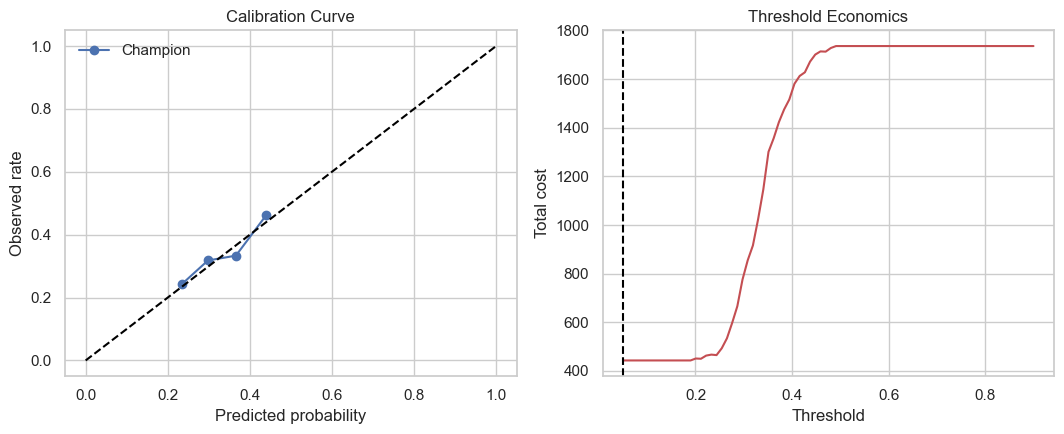

Champion model: RandomForest
Cost-optimal threshold: 0.050 | Precision=0.329 | Recall=1.000


In [28]:
champ_name = bench.iloc[0]["model"]
champ_model, p_test = preds[champ_name]

frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=12)

fig, ax = plt.subplots(1, 2, figsize=(10.8, 4.5))

ax[0].plot(mean_pred, frac_pos, marker="o", color="#4C72B0", label="Champion")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="black")
ax[0].set_title("Calibration Curve")
ax[0].set_xlabel("Predicted probability")
ax[0].set_ylabel("Observed rate")
ax[0].legend()

thresholds = np.linspace(0.05, 0.9, 80)
fp_cost = 1.0
fn_cost = 8.0
cost_rows = []
for t in thresholds:
    pred = (p_test >= t).astype(int)
    fp = ((pred == 1) & (y_test.values == 0)).sum()
    fn = ((pred == 0) & (y_test.values == 1)).sum()
    tp = ((pred == 1) & (y_test.values == 1)).sum()
    total_cost = fp_cost * fp + fn_cost * fn
    precision = tp / max((pred == 1).sum(), 1)
    recall = tp / max((y_test.values == 1).sum(), 1)
    cost_rows.append({"threshold": t, "total_cost": total_cost, "precision": precision, "recall": recall})

cost_df = pd.DataFrame(cost_rows)
best = cost_df.sort_values("total_cost").iloc[0]

ax[1].plot(cost_df["threshold"], cost_df["total_cost"], color="#C44E52")
ax[1].axvline(best["threshold"], linestyle="--", color="black")
ax[1].set_title("Threshold Economics")
ax[1].set_xlabel("Threshold")
ax[1].set_ylabel("Total cost")

plt.tight_layout()
plt.show()

print(f"Champion model: {champ_name}")
print(f"Cost-optimal threshold: {best['threshold']:.3f} | Precision={best['precision']:.3f} | Recall={best['recall']:.3f}")

In [29]:
def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10):
    quantiles = np.quantile(expected, np.linspace(0, 1, bins + 1))
    quantiles[0] = -np.inf
    quantiles[-1] = np.inf

    e_counts, _ = np.histogram(expected, bins=quantiles)
    a_counts, _ = np.histogram(actual, bins=quantiles)

    e_dist = np.clip(e_counts / max(e_counts.sum(), 1), 1e-6, None)
    a_dist = np.clip(a_counts / max(a_counts.sum(), 1), 1e-6, None)

    psi = np.sum((a_dist - e_dist) * np.log(a_dist / e_dist))
    return float(psi)

# Proxy "time" split: first half of test vs second half
test_scores = pd.DataFrame({"score": p_test, "y": y_test.values}).reset_index(drop=True)
mid = len(test_scores) // 2
psi_value = population_stability_index(test_scores.loc[:mid, "score"].to_numpy(), test_scores.loc[mid+1:, "score"].to_numpy())

psi_band = "stable" if psi_value < 0.1 else ("moderate shift" if psi_value < 0.25 else "major shift")
print(f"Score PSI (proxy time split): {psi_value:.4f} -> {psi_band}")

Score PSI (proxy time split): 0.0462 -> stable


In [30]:
# Subgroup monitoring on first available categorical feature
monitor_col = cat_cols[0] if len(cat_cols) > 0 else None
if monitor_col is None:
    subgroup_table = pd.DataFrame({"note": ["No categorical feature available for subgroup monitoring"]})
else:
    sg = X_test.copy()
    sg["y"] = y_test.values
    sg["score"] = p_test

    rows = []
    for v, sub in sg.groupby(monitor_col):
        if len(sub) < 50:
            continue
        rows.append(
            {
                "group": str(v),
                "n": len(sub),
                "event_rate": sub["y"].mean(),
                "avg_score": sub["score"].mean(),
                "calibration_gap": sub["score"].mean() - sub["y"].mean(),
            }
        )
    subgroup_table = pd.DataFrame(rows).sort_values("calibration_gap", key=np.abs, ascending=False)

subgroup_table.head(10)

,group,n,event_rate,avg_score,calibration_gap
0,female,354,0.319209,0.324556,0.005347
1,male,306,0.339869,0.336427,-0.003442


In [31]:
governance_scorecard = pd.Series(
    {
        "selected_model": champ_name,
        "roc_auc": float(bench.loc[bench['model'] == champ_name, 'roc_auc'].iloc[0]),
        "pr_auc": float(bench.loc[bench['model'] == champ_name, 'pr_auc'].iloc[0]),
        "brier": float(bench.loc[bench['model'] == champ_name, 'brier'].iloc[0]),
        "optimal_threshold": float(best["threshold"]),
        "psi_proxy_time_split": psi_value,
        "psi_band": psi_band,
        "max_abs_subgroup_calibration_gap": float(np.abs(subgroup_table["calibration_gap"]).max()) if "calibration_gap" in subgroup_table.columns and len(subgroup_table) else np.nan,
    }
)
governance_scorecard

selected_model                      RandomForest
roc_auc                                 0.536424
pr_auc                                  0.380854
brier                                   0.219867
optimal_threshold                           0.05
psi_proxy_time_split                    0.046152
psi_band                                  stable
max_abs_subgroup_calibration_gap        0.005347
dtype: object

### Interpretation

- This module turns modeling output into governance artifacts suitable for peer review.
- Cost-optimal thresholding makes operating policy explicit instead of implicit.
- PSI and subgroup calibration gaps provide practical early-warning signals for retraining and control actions.